In [1]:
import os
import sys
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

from models.autoencoder import Autoenc

In [2]:
def knn_consistency(knn1, knn2, ks, leniency=0., eps=1e-8):
    N, k_max = knn1.shape
    
    assert int(ks[-1] * (1 + leniency)) <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        compare_k = int(k * (1 + leniency))
        shared = ranking[np.arange(N)[:, None], neighbours] < compare_k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        #ev = k * compare_k / (N - 1)  # Hypergeometric distribution with m=k
        #overlap = (num_shared - ev + eps) / (k - ev + eps)  # Chance adjust
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

In [3]:
X1 = np.random.rand(100, 64)
X2 = np.random.rand(100, 64)

k = 4

nn1 = NearestNeighbors(n_neighbors=k).fit(X1)
knn1 = nn1.kneighbors(return_distance=False)
nn2 = NearestNeighbors(n_neighbors=k).fit(X2)
knn2 = nn2.kneighbors(return_distance=False)

knn_consistency(knn1, knn2, [4])

array([0.0275])

In [4]:
model_paths_128 = [
    'runs/base/exp12/model_weights.pth',
    'runs/base/exp13/model_weights.pth',
    'runs/base/exp14/model_weights.pth',
]

model_paths_64 = [
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
]

model_paths_overcomplete = [
    'runs/base/exp9/model_weights.pth',
    'runs/base/exp10/model_weights.pth',
    'runs/base/exp11/model_weights.pth',
]


def get_features(model_paths):
    all_features = []
    for model_path in model_paths:
        cp = torch.load(model_path)

        features = []
        for key, value in cp.items():
            if 'readout' in key and 'features' in key:
                features.append(value.cpu().squeeze().T)
        features = torch.cat(features)

        all_features.append(features)
    return all_features

In [5]:
features_128 = get_features(model_paths_128)
features_64 = get_features(model_paths_64)
features_overcomplete = get_features(model_paths_overcomplete)

In [9]:
N = features_64[0].shape[0]

In [10]:
N

54569

In [11]:
def get_curve(k_range, all_features):
    #k_range = np.unique(np.geomspace(1, 500, num=20, dtype=int))
    #leniency_range = [0., 0.1, 0.2, 0.5, 1.]
    #leniency_range = [0.]
    #consistencies_dict = {}
    #consistencies = []

    knns = []
    for features in all_features:
        #max_compare_k = int(k_range[-1] * (1 + leniency_range[-1]))
        max_compare_k = k_range[-1]
        nn = NearestNeighbors(n_neighbors=max_compare_k).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    curve = (
        knn_consistency(knns[0], knns[1], ks=k_range,)# leniency=leniency)
        #+ knn_consistency(knns[0], knns[2], ks=k_range,)# leniency=leniency)
        #+ knn_consistency(knns[1], knns[2], ks=k_range,)# leniency=leniency)
    ) #/ 3

    #consistencies_dict[leniency] = avg_curve
    return curve, knns

In [12]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
base_curve_128, knns128 = get_curve(k_range, features_128)
base_curve_64, knns64 = get_curve(k_range, features_64)
base_curve_overcomplete, knns_overcomplete = get_curve(k_range, features_overcomplete)

In [13]:
features_overcomplete[1][0, :64], features_overcomplete[1][0, 64:]

(tensor([-0.0096, -0.0180, -0.0264,  0.0749,  0.0063,  0.2658, -0.0820, -0.0561,
          0.1653,  0.0176, -0.1245, -0.1753,  0.2200, -0.3287,  0.1954, -0.2252,
          0.0279, -0.0605, -0.0040, -0.2298,  0.4629,  0.1791,  0.1681,  0.0643,
         -0.2228, -0.2792,  0.1345, -0.1939,  0.1925, -0.1176, -0.3273, -0.0967,
         -0.1985, -0.2350, -0.1376, -0.2701,  0.0742,  0.0956, -0.1535, -0.4355,
         -0.0169, -0.2315, -0.1002,  0.0088,  0.2334, -0.1953, -0.0514, -0.3633,
          0.3031, -0.2691,  0.1738,  0.3460,  0.0636,  0.0145,  0.0951,  0.0274,
          0.0168, -0.3214,  0.1758, -0.0513,  0.1892,  0.0162, -0.2338, -0.0014]),
 tensor([-0.0096, -0.0180, -0.0264,  0.0749,  0.0063,  0.2658, -0.0820, -0.0561,
          0.1653,  0.0176, -0.1245, -0.1753,  0.2200, -0.3287,  0.1954, -0.2252,
          0.0279, -0.0605, -0.0040, -0.2298,  0.4629,  0.1791,  0.1681,  0.0643,
         -0.2228, -0.2792,  0.1345, -0.1939,  0.1925, -0.1176, -0.3273, -0.0967,
         -0.1985, -0.2350,

In [14]:
(features_overcomplete[0][:, :64] == features_overcomplete[0][:, 64:]).all()

tensor(True)

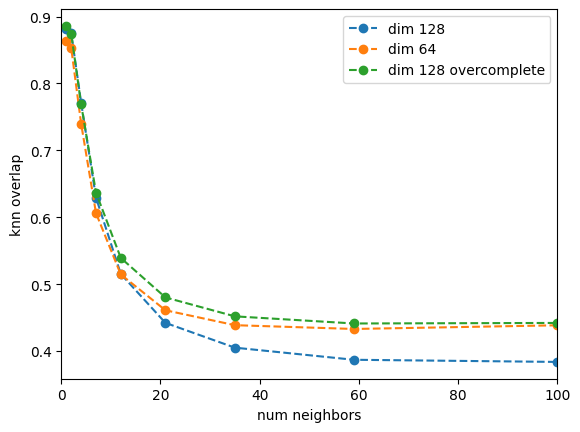

In [15]:
curves = [base_curve_128, base_curve_64, base_curve_overcomplete]
labels = ['dim 128', 'dim 64', 'dim 128 overcomplete']
for curve, label in zip(curves, labels):
    plt.plot(k_range, curve, ls='--', marker='o', label=label)

plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.xlim(0, 100)
plt.savefig('plots/knn_overlap_overcomplete.png')
plt.show()

In [17]:
features_overcomplete[0][0]

tensor([-1.4712e-01, -7.7191e-02, -2.8764e-04, -7.2811e-05, -1.7736e-02,
        -7.4998e-05, -2.1315e-04, -6.3201e-05, -2.5848e-05, -1.7636e-05,
        -7.2935e-05, -2.8751e-04, -6.2294e-05,  5.1557e-05,  7.2188e-03,
        -8.7861e-03, -1.5489e-02, -8.1719e-05, -1.4195e-04, -4.8342e-05,
        -9.3116e-05, -1.5331e-04, -1.0525e-04,  2.4434e-03, -2.4364e-05,
        -1.7426e-01, -1.1677e-01, -4.1617e-03, -1.7510e-03, -7.5364e-05,
        -1.6121e-04,  5.7933e-03, -4.8239e-05, -2.2824e-06, -3.6727e-02,
        -2.1036e-02,  1.1390e-02, -1.6240e-02, -3.3678e-02,  5.3843e-02,
        -4.6723e-02,  6.9490e-03,  2.8621e-02,  3.8629e-02, -4.4486e-05,
         6.4308e-02,  4.9349e-02,  5.8418e-04, -6.9035e-05,  4.6468e-05,
        -9.6776e-03, -8.4034e-05, -8.0646e-02,  1.3981e-02,  1.1018e-01,
         7.3593e-02, -7.2673e-03, -5.9744e-02, -1.4117e-02,  3.4147e-05,
        -7.7931e-02, -4.8066e-05, -1.8331e-02, -3.4552e-02, -1.4712e-01,
        -7.7191e-02, -2.8764e-04, -7.2811e-05, -1.7

In [ ]:
i = 2
(features_overcomplete[i][:, :64] == features_overcomplete[i][:, 64:]).all()

tensor(True)

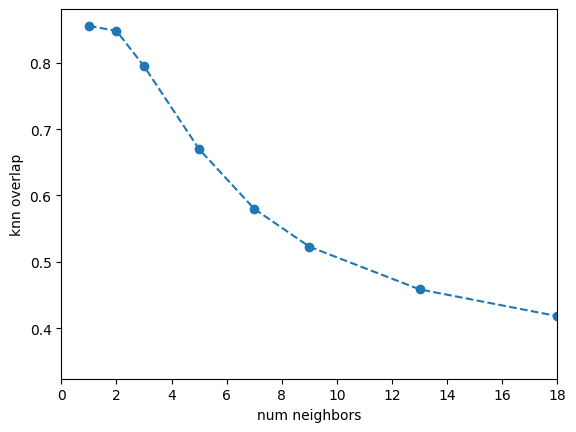

In [ ]:
#for leniency, curve in consistencies_dict.items():
plt.plot(k_range, avg_curve, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
#plt.xscale('log')
plt.xlim(0, 18)
#plt.legend(title='leniency')
plt.savefig('plots/knn_overlap_zoom.png')
plt.show()

In [13]:
latent_dims = [32, 16, 8, 4, 2]

autoenc_paths = [
    [
        'runs/recon_autoenc/exp3/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp4/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp5/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp6/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp7/autoencoder_weights.pth', 
    ],
    [
        'runs/recon_autoenc/exp8/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp9/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp10/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp11/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp12/autoencoder_weights.pth', 
    ],
    [
        'runs/recon_autoenc/exp13/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp14/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp15/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp16/autoencoder_weights.pth', 
        'runs/recon_autoenc/exp17/autoencoder_weights.pth', 
    ],
]

autoencoder_config = {
    'input_dim': 64,
    'hidden_dims': [256, 256, 256],
    'batch_norm': False,
    'nonlinearity': 'ReLU',
}

In [31]:
ks = np.unique(np.geomspace(1, 500, num=20, dtype=int))
knn_curves = []

for i, latent_dim in enumerate(latent_dims):
    print(latent_dim)
    knns = []
    for num_model in range(3):
        autoenc_path = autoenc_paths[num_model][i]
        autoenc = Autoenc(latent_dim=latent_dim, **autoencoder_config)
        autoenc.load_state_dict(torch.load(autoenc_path))
        
        features = all_features[num_model]
        enc_features = autoenc(features).detach().numpy()

        nn = NearestNeighbors(n_neighbors=ks[-1]).fit(enc_features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    knn_curve = (
        knn_consistency(knns[0], knns[1], ks=ks)
        + knn_consistency(knns[0], knns[2], ks=ks)
        + knn_consistency(knns[1], knns[2], ks=ks)
    ) / 3

    knn_curves.append(knn_curve)

32
16
8
4
2


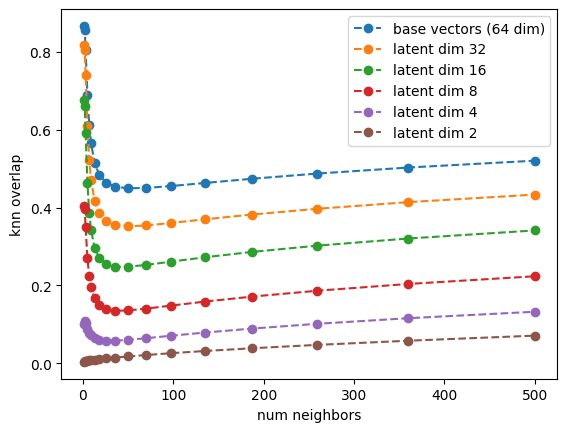

In [40]:
#for leniency, curve in consistencies_dict.items():
plt.plot(ks, base_curve, ls='--', marker='o', label='base vectors (64 dim)')
for latent_dim, curve in zip(latent_dims, knn_curves):
    plt.plot(ks, curve, ls='--', marker='o', label=f'latent dim {latent_dim}')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.legend()
plt.savefig('plots/knn_overlap.png')
plt.show()

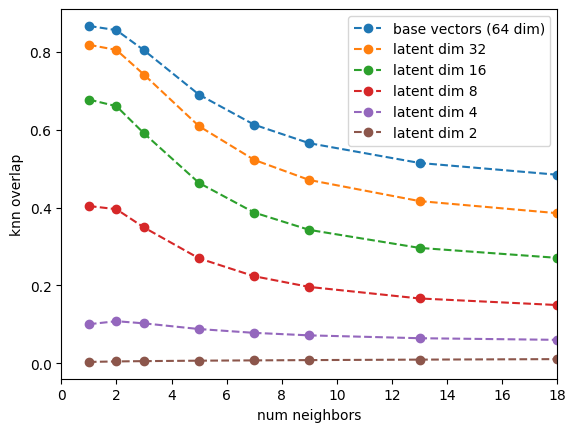

In [41]:
#for leniency, curve in consistencies_dict.items():
plt.plot(ks, base_curve, ls='--', marker='o', label='base vectors (64 dim)')
for latent_dim, curve in zip(latent_dims, knn_curves):
    plt.plot(ks, curve, ls='--', marker='o', label=f'latent dim {latent_dim}')

plt.xlabel('num neighbors')
plt.ylabel('knn overlap')
plt.legend()
plt.xlim(0, 18)
plt.savefig('plots/knn_overlap_zoom.png')
plt.show()